# TiranaFly — Geospatial Infrastructure & Map Modeling
## Logistics Optimization for TiranaFly — Drone Delivery Network, Tirana

**Course:** Discrete Structures & Algorithms — Project #1  
**Professor:** Prof. Dr. Fatos Xhafa  
**Semester:** 2, 2026

---

### Module Purpose
This notebook builds the **complete geospatial foundation** for the TiranaFly drone delivery network.  
It covers every step needed before routing or fleet optimization can begin:

| Step | Task |
|------|------|
| 0 | Import libraries |
| 1 | Define the Tirana coordinate grid & drone parameters |
| 2 | Partition Tirana into **8 real-world zones** (North, East, South-East, Center, West, South-West, South, South-East Outer) |
| 3 | Place **depots** (zones 1=North, 3=South-East, 5=West, 7=South each get a depot) and generate **16 clients per zone** |
| 4 | Compute Euclidean edge weights |
| 5 | Build a **complete weighted graph** per zone — ready for Dijkstra in the next module |
| 6 | Visualise the map (geometry mirrors the real Tirana district layout) |
| 7 | Export node/edge tables for the routing and fleet modules |

> **Drone spec (shared constants):** max payload **4.0 kg**, max range **D_MAX = 15 km**.


---
## Step 0 — Install & Import Libraries

In [1]:
# ─── Required libraries ────────────────────────────────────────────────────────
# Uncomment the line below if running for the first time in a fresh environment:
# !pip install networkx matplotlib numpy pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import networkx as nx
import math, random

# Fix random seed so results are reproducible across all team members
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## Step 1 — Tirana Coordinate Grid & Drone Parameters

Tirana is modelled as a **20 km × 20 km** 2-D plane:
- `x` ∈ [0, 20] km  →  West to East  
- `y` ∈ [0, 20] km  →  South to North  
- City centre (used as the geometric anchor): **(10, 10)**

### Drone specification
| Parameter | Value | Unit |
|-----------|-------|------|
| Max flight range D_MAX | 15.0 | km |
| Max payload | 4.0 | kg |

A delivery route is **feasible** only when its total Euclidean length ≤ D_MAX.  
Battery consumed = k × distance (linear model).


In [2]:
# ─── Tirana Grid ──────────────────────────────────────────────────────────────
GRID_MIN_X, GRID_MAX_X = 0, 20   # km, West → East
GRID_MIN_Y, GRID_MAX_Y = 0, 20   # km, South → North
CENTER_X = (GRID_MAX_X + GRID_MIN_X) / 2   # 10.0
CENTER_Y = (GRID_MAX_Y + GRID_MIN_Y) / 2   # 10.0

# ─── Drone Parameters (shared across all project modules) ─────────────────────
D_MAX        = 15.0   # Maximum drone flight range (km)
MAX_PAYLOAD  = 4.0    # Maximum cargo weight per flight (kg)

print(f"Grid : x ∈ [{GRID_MIN_X}, {GRID_MAX_X}] km  |  y ∈ [{GRID_MIN_Y}, {GRID_MAX_Y}] km")
print(f"Centre: ({CENTER_X}, {CENTER_Y})")
print(f"Drone : D_MAX={D_MAX} km | Payload={MAX_PAYLOAD} kg")


Grid : x ∈ [0, 20] km  |  y ∈ [0, 20] km
Centre: (10.0, 10.0)
Drone : D_MAX=15.0 km | Payload=4.0 kg


---
## Step 2 — Zone Partitioning: 8 Real-World Districts

The city is divided into the **8 official administrative zones** of Tirana  
(matching the "Tirana – 8 Neighborhood" map):

| # |  Area | Area share | Neighbourhoods |
|---|---------|-----------|----------------|
| 1 | North | 17.2 % | Bërxullë, Kashar, Yzberisht |
| 2 | East | 16.8 % | Dajt, Paskuqan, Shën Koll |
| 3 | South-East | 14.3 % | Liqeni Artificial, Selitë, Kombinat |
| 4 | Centre | 15.5 % | Sheshi Skënderbej, Blloku, Pazari i Ri |
| 5 | West | 13.1 % | Kashar, Vaqarr, Mezez |
| 6 | South-West | 11.8 % | Laprakë, Don Bosko, Ali Demi |
| 7 | South | 10.6 % | Komuna e Parisit, Myslym Shyri, Kodra e Diellit |
| 8 | South-East outer | 10.7 % | Farkë, Qesarak, Petrelë |

Each zone is represented as a **convex polygon** whose vertices approximate the  
real district boundaries from the reference map.  
Depot placement: **Zones 1 (North), 3 (South-East), 5 (West) and 7 (South)** each receive one depot.


In [3]:
# ─── 8-Zone Definitions ───────────────────────────────────────────────────────
# Each zone stores:
#   poly   – list of (x,y) vertices that approximate the district boundary
#   color  – display colour (matches the reference map)
#   depot  – True/False  (only zones 1, 4, 5 have a depot)
#   depot_pos – (x, y) coordinate for the depot node (outskirts of zone)
#
# Coordinate system: (0,0)=SW corner, (20,20)=NE corner of the 20×20 km grid.
# Polygons are manually fitted to match the real Tirana district shapes.

ZONES = {
    'North': {
        'id': 1, 'color': '#5B9BD5',
        'depot': True,
        'depot_pos': (10.0, 18.5),          # northern outskirt
        'poly': [(5,13),(8,14),(10,20),(14,20),(16,14),(13,12),(10,11),(7,11)],
        'area_pct': 17.2,
        'neighbourhoods': 'Bërxullë, Kashar, Yzberisht'
    },
    'East': {
        'id': 2, 'color': '#70AD47',
        'depot': False,
        'depot_pos': (16.5, 13.5),
        'poly': [(13,12),(16,14),(20,14),(20,10),(17,9),(14,10),(13,11)],
        'area_pct': 16.8,
        'neighbourhoods': 'Dajt, Paskuqan, Shën Koll'
    },
    'South-East': {
        'id': 3, 'color': '#FFC000',
        'depot': True,
        'depot_pos': (16.5, 7.0),
        'poly': [(14,10),(17,9),(20,10),(20,5),(16,4),(13,6),(12,8),(13,9)],
        'area_pct': 14.3,
        'neighbourhoods': 'Liqeni Artificial, Selitë, Kombinat'
    },
    'Center': {
        'id': 4, 'color': '#FF6B6B',
        'depot': False,
        'depot_pos': (10.0, 10.5),          # city-centre depot
        'poly': [(7,11),(10,11),(13,11),(13,9),(12,8),(10,7),(8,7),(7,9)],
        'area_pct': 15.5,
        'neighbourhoods': 'Sheshi Skënderbej, Blloku, Pazari i Ri'
    },
    'West': {
        'id': 5, 'color': '#ED7D31',
        'depot': True,
        'depot_pos': (2.5, 12.0),           # western outskirt
        'poly': [(0,14),(5,13),(7,11),(7,9),(5,8),(2,9),(0,10)],
        'area_pct': 13.1,
        'neighbourhoods': 'Kashar, Vaqarr, Mezez'
    },
    'South-West': {
        'id': 6, 'color': '#00B0A0',
        'depot': False,
        'depot_pos': (4.0, 6.0),
        'poly': [(0,10),(2,9),(5,8),(7,9),(8,7),(6,4),(2,4),(0,6)],
        'area_pct': 11.8,
        'neighbourhoods': 'Laprakë, Don Bosko, Ali Demi'
    },
    'South': {
        'id': 7, 'color': '#9966CC',
        'depot': True,
        'depot_pos': (9.0, 4.0),
        'poly': [(6,4),(8,7),(10,7),(12,8),(13,6),(12,3),(9,2),(6,3)],
        'area_pct': 10.6,
        'neighbourhoods': 'Komuna e Parisit, Myslym Shyri, Kodra e Diellit'
    },
    'South-East Outer': {
        'id': 8, 'color': '#FF99AA',
        'depot': False,
        'depot_pos': (15.5, 3.5),
        'poly': [(13,6),(16,4),(20,5),(20,0),(14,0),(10,1),(9,2),(12,3),(13,4)],
        'area_pct': 10.7,
        'neighbourhoods': 'Farkë, Qesarak, Petrelë'
    },
}

print("Zone definitions loaded:")
print(f"{'#':<3} {'Zone':<14} {'Depot':<7} {'Area%':<8} {'Depot pos'}")
print("-"*55)
for z, info in ZONES.items():
    d = "YES ★" if info['depot'] else "no"
    print(f"{info['id']:<3} {z:<14} {d:<7} {info['area_pct']:<8} {info['depot_pos']}")


Zone definitions loaded:
#   Zone           Depot   Area%    Depot pos
-------------------------------------------------------
1   North          YES ★   17.2     (10.0, 18.5)
2   East           no      16.8     (16.5, 13.5)
3   South-East     YES ★   14.3     (16.5, 7.0)
4   Center         no      15.5     (10.0, 10.5)
5   West           YES ★   13.1     (2.5, 12.0)
6   South-West     no      11.8     (4.0, 6.0)
7   South          YES ★   10.6     (9.0, 4.0)
8   South-East Outer no      10.7     (15.5, 3.5)


---
## Step 3 — Depot & Client Generation

For **each of the 8 zones**:
- If the zone has a depot (`depot=True`): one **Depot** node is placed at `depot_pos` (outskirts).
- **16 clients** are generated as random (x, y) points **inside** the zone polygon (rejection sampling).

All nodes are stored in a flat list and a per-zone dictionary.  
Node IDs follow the pattern `Z{id}_Depot` and `Z{id}_C{n}`.

> Zones with depots: **North (Z1)**, **South-East (Z3)**, **West (Z5)**, **South (Z7)**.  
> These four depots are the origin points for all Dijkstra routes in the routing module.


In [4]:
# ─── Helper: point-in-polygon test (ray-casting) ──────────────────────────────
def point_in_polygon(x, y, poly):
    """Return True if point (x,y) lies inside the polygon defined by vertices poly."""
    n = len(poly)
    inside = False
    px, py = x, y
    j = n - 1
    for i in range(n):
        xi, yi = poly[i]
        xj, yj = poly[j]
        if ((yi > py) != (yj > py)) and (px < (xj - xi) * (py - yi) / (yj - yi) + xi):
            inside = not inside
        j = i
    return inside

# ─── Helper: generate random clients inside a polygon ─────────────────────────
def generate_clients_in_polygon(zone_name, zone_info, n_clients):
    """
    Generate n_clients random nodes strictly inside the zone polygon.
    Uses rejection sampling: draw a random point in the bounding box,
    keep it only if it falls inside the polygon.
    Returns a list of node dicts: {id, x, y, type, zone}.
    """
    poly = zone_info['poly']
    xs = [p[0] for p in poly]; ys = [p[1] for p in poly]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    zid = zone_info['id']
    clients = []
    attempts = 0
    while len(clients) < n_clients and attempts < 100_000:
        cx = random.uniform(x_min, x_max)
        cy = random.uniform(y_min, y_max)
        attempts += 1
        if point_in_polygon(cx, cy, poly):
            clients.append({
                'id':   f"Z{zid}_C{len(clients)+1}",
                'x':    round(cx, 4),
                'y':    round(cy, 4),
                'type': 'client',
                'zone': zone_name
            })
    if len(clients) < n_clients:
        print(f"⚠ Zone {zone_name}: only {len(clients)}/{n_clients} clients fit (polygon too small?)")
    return clients

# ─── Generate all nodes ───────────────────────────────────────────────────────
NC_PER_ZONE = 16   # exactly 16 clients per zone (project specification)

zone_nodes = {}    # zone_name → list of node dicts (depot if any + clients)
all_nodes  = []    # flat list

for zone_name, zone_info in ZONES.items():
    nodes = []
    zid = zone_info['id']

    # Depot (only in zones 1, 3, 5, 7 (North, South-East, West, South))
    if zone_info['depot']:
        dx, dy = zone_info['depot_pos']
        nodes.append({'id': f"Z{zid}_Depot", 'x': dx, 'y': dy,
                      'type': 'depot', 'zone': zone_name})

    # 16 clients
    nodes += generate_clients_in_polygon(zone_name, zone_info, NC_PER_ZONE)
    zone_nodes[zone_name] = nodes
    all_nodes.extend(nodes)

df_nodes = pd.DataFrame(all_nodes)
print("\nNode summary:")
print(df_nodes.groupby(['zone','type']).size().unstack(fill_value=0).to_string())
print(f"\nTotal nodes: {len(df_nodes)}  "
      f"(depots: {len(df_nodes[df_nodes.type=='depot'])}, "
      f"clients: {len(df_nodes[df_nodes.type=='client'])})")



Node summary:
type              client  depot
zone                           
Center                16      0
East                  16      0
North                 16      1
South                 16      1
South-East            16      1
South-East Outer      16      0
South-West            16      0
West                  16      1

Total nodes: 132  (depots: 4, clients: 128)


---
## Step 4 — Euclidean Distance (Edge Weight)

Every edge weight equals the **Euclidean (straight-line) distance** between two nodes:

$$d(u, v) = \sqrt{(x_u - x_v)^2 + (y_u - y_v)^2} \quad \text{(km)}$$

This is the **L2 norm** (Euclidean norm) of the displacement vector.  
It serves as a proxy for flight distance under the linear battery model:  

An edge is marked **feasible** when d(u, v) ≤ D_MAX = 15 km.  



In [5]:
# ─── Euclidean distance (L2 norm) ─────────────────────────────────────────────
def euclidean_distance(node_a, node_b):
    """
    Compute the Euclidean (L2) distance between two node dicts (each with 'x','y').
    Returns distance in km.
    Reference: standard 2-D Euclidean norm.
    """
    return math.sqrt((node_a['x'] - node_b['x'])**2 +
                     (node_a['y'] - node_b['y'])**2)

# Sanity check (3-4-5 right triangle)
assert abs(euclidean_distance({'x':0,'y':0}, {'x':3,'y':4}) - 5.0) < 1e-9
print("✅ Euclidean distance function verified  (3,4 → 5.0 km)")


✅ Euclidean distance function verified  (3,4 → 5.0 km)


---
## Step 5 — Complete Weighted Graph Construction

For **each zone** we build a **complete graph** G = (V, E):

- **V** = all nodes in the zone (depot if present + 16 clients)  
- **E** = every pair of nodes is connected (n·(n−1)/2 edges)  
- **weight** of each edge = Euclidean distance in km  
- **feasible** attribute = True if weight ≤ D_MAX

### Why a complete graph?
A complete graph guarantees that Dijkstra's algorithm  can always  
find *some* path from the depot to any client.  
Edges that exceed D_MAX are flagged but not removed — the routing module will  
use them only in multi-hop paths whose *total* length stays within battery range.

Data structures exported:
- `zone_graphs[z]`    — `networkx.Graph` with `weight` and `feasible` edge attributes  
- `zone_adj_lists[z]` — plain Python adjacency list `{node_id: [(neighbour, weight), …]}`


In [6]:
# ─── Build complete weighted graph per zone ───────────────────────────────────
def build_complete_graph(nodes):
    """
    Build a complete weighted undirected graph from a list of node dicts.

    Parameters
    ----------
    nodes : list of dicts, each with keys 'id', 'x', 'y', 'type', 'zone'

    Returns
    -------
    adj_list : dict  node_id → [(neighbour_id, weight_km), ...]
    G        : networkx.Graph  with node attributes and edge weight/feasible attrs
    """
    G = nx.Graph()
    adj_list = {}

    # Add nodes
    for n in nodes:
        G.add_node(n['id'], **n)
        adj_list[n['id']] = []

    # Add edges (complete: every pair)
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u, v = nodes[i], nodes[j]
            w = round(euclidean_distance(u, v), 6)
            feasible = w <= D_MAX
            G.add_edge(u['id'], v['id'], weight=w, feasible=feasible)
            adj_list[u['id']].append((v['id'], w))
            adj_list[v['id']].append((u['id'], w))

    return adj_list, G


zone_adj_lists = {}
zone_graphs    = {}

for zone_name, nodes in zone_nodes.items():
    adj, G = build_complete_graph(nodes)
    zone_adj_lists[zone_name] = adj
    zone_graphs[zone_name]    = G

# Verify completeness
print(f"{'Zone':<14} {'Nodes':>6} {'Edges':>7} {'Expected':>9} {'Complete?':>10}")
print("-" * 50)
for z, G in zone_graphs.items():
    n = G.number_of_nodes()
    e = G.number_of_edges()
    exp = n * (n - 1) // 2
    ok = "✅" if e == exp else "❌"
    print(f"{z:<14} {n:>6} {e:>7} {exp:>9} {ok:>10}")
print("\n✅ All zone graphs verified as complete.")


Zone            Nodes   Edges  Expected  Complete?
--------------------------------------------------
North              17     136       136          ✅
East               16     120       120          ✅
South-East         17     136       136          ✅
Center             16     120       120          ✅
West               17     136       136          ✅
South-West         16     120       120          ✅
South              17     136       136          ✅
South-East Outer     16     120       120          ✅

✅ All zone graphs verified as complete.


---
## Step 6 — Adjacency List Preview

In [7]:
# ─── Pretty-print a sample of each zone's adjacency list ──────────────────────
def show_adjacency_list(adj, zone_name, max_nodes=4, max_nbrs=3):
    """
    Print the closest neighbours of the first max_nodes nodes in a zone.
    Sorted by distance so the nearest neighbours appear first.
    """
    print(f"\n── Zone: {zone_name} (top-{max_nbrs} nearest neighbours per node) ──")
    for nid, nbrs in list(adj.items())[:max_nodes]:
        top = sorted(nbrs, key=lambda x: x[1])[:max_nbrs]
        line = "  |  ".join(f"{nb} ({w:.2f} km)" for nb, w in top)
        print(f"  {nid:<14} →  {line}")

for z in ZONES:
    show_adjacency_list(zone_adj_lists[z], z)



── Zone: North (top-3 nearest neighbours per node) ──
  Z1_Depot       →  Z1_C11 (1.55 km)  |  Z1_C12 (2.67 km)  |  Z1_C5 (3.37 km)
  Z1_C1          →  Z1_C15 (0.79 km)  |  Z1_C7 (0.94 km)  |  Z1_C16 (2.15 km)
  Z1_C2          →  Z1_C6 (0.79 km)  |  Z1_C10 (0.91 km)  |  Z1_C13 (1.15 km)
  Z1_C3          →  Z1_C7 (1.44 km)  |  Z1_C1 (2.38 km)  |  Z1_C15 (3.16 km)

── Zone: East (top-3 nearest neighbours per node) ──
  Z2_C1          →  Z2_C6 (0.67 km)  |  Z2_C14 (1.16 km)  |  Z2_C10 (1.50 km)
  Z2_C2          →  Z2_C12 (0.21 km)  |  Z2_C15 (0.73 km)  |  Z2_C4 (1.22 km)
  Z2_C3          →  Z2_C10 (0.48 km)  |  Z2_C14 (0.76 km)  |  Z2_C15 (1.36 km)
  Z2_C4          →  Z2_C8 (0.74 km)  |  Z2_C12 (1.07 km)  |  Z2_C2 (1.22 km)

── Zone: South-East (top-3 nearest neighbours per node) ──
  Z3_Depot       →  Z3_C7 (0.98 km)  |  Z3_C15 (1.62 km)  |  Z3_C16 (1.74 km)
  Z3_C1          →  Z3_C11 (0.85 km)  |  Z3_C14 (1.72 km)  |  Z3_Depot (2.13 km)
  Z3_C2          →  Z3_C5 (0.12 km)  |  Z3_C4 (1.

---
## Step 7 — Map Visualisation

The figure below mirrors the **real Tirana district layout**:
- Zone polygons match the reference map (Tirana – 8 Neighborhood).
- Depot nodes are shown as large red stars ★ in zones West, Center, South-East.
- Client nodes are shown as small circles coloured by zone.
- Grey edges inside each zone represent the complete graph (drawn lightly to avoid clutter).


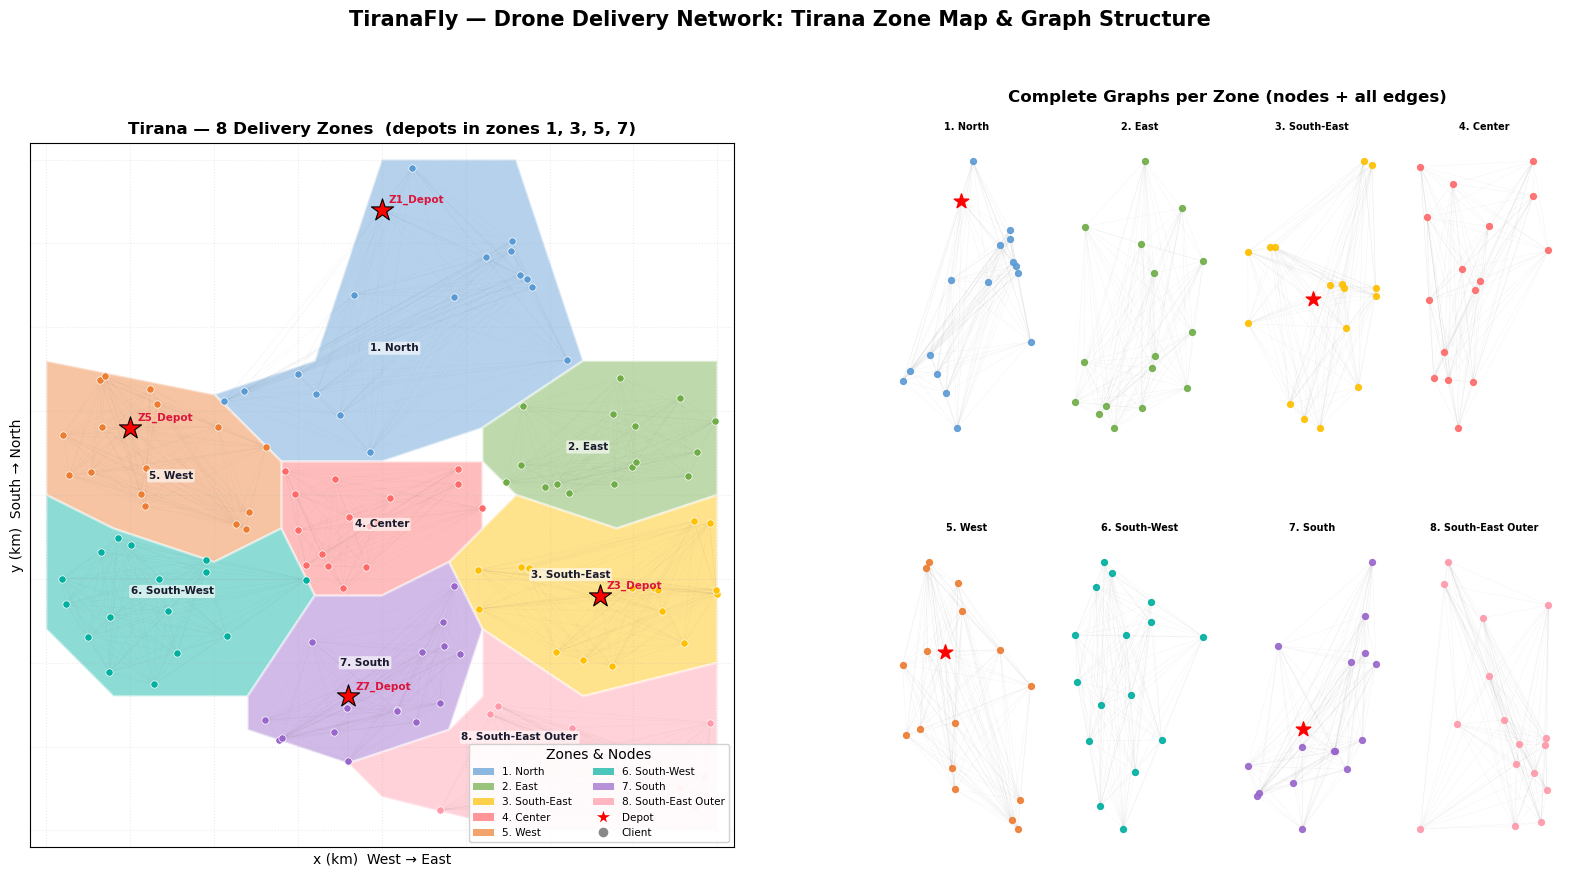

✅ Map saved → tirana_map.png


In [8]:
# ─── Visualisation: Tirana map + complete graphs ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("TiranaFly — Drone Delivery Network: Tirana Zone Map & Graph Structure",
             fontsize=15, fontweight='bold')

# ── Left panel: Zone polygons + nodes ─────────────────────────────────────────
ax = axes[0]
ax.set_title("Tirana — 8 Delivery Zones  (depots in zones 1, 3, 5, 7)", fontsize=12, fontweight='bold')

for zone_name, info in ZONES.items():
    poly_pts = np.array(info['poly'])
    patch = MplPolygon(poly_pts, closed=True,
                       facecolor=info['color'], edgecolor='white',
                       linewidth=1.8, alpha=0.45, zorder=1)
    ax.add_patch(patch)

    # Zone label (number + name)
    cx = np.mean(poly_pts[:,0])
    cy = np.mean(poly_pts[:,1])
    ax.text(cx, cy, f"{info['id']}. {zone_name}", ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='#1a1a2e', zorder=4,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.6, edgecolor='none'))

# Plot edges (per zone, very faint)
for zone_name, G in zone_graphs.items():
    pos = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.04, width=0.4, edge_color='#555555')

# Plot clients
for zone_name, info in ZONES.items():
    color = info['color']
    for node in zone_nodes[zone_name]:
        if node['type'] == 'client':
            ax.scatter(node['x'], node['y'], c=color, s=28, zorder=3,
                       edgecolors='white', linewidths=0.5)

# Plot depots (on top)
for zone_name, info in ZONES.items():
    if info['depot']:
        for node in zone_nodes[zone_name]:
            if node['type'] == 'depot':
                ax.scatter(node['x'], node['y'], c='red', s=280,
                           marker='*', zorder=6, edgecolors='black', linewidths=0.8)
                ax.annotate(node['id'], (node['x'], node['y']),
                            textcoords='offset points', xytext=(5, 5),
                            fontsize=7.5, fontweight='bold', color='crimson', zorder=7)

ax.set_xlim(-0.5, 20.5); ax.set_ylim(-0.5, 20.5)
ax.set_xlabel("x (km)  West → East"); ax.set_ylabel("y (km)  South → North")
ax.grid(True, alpha=0.25, linestyle=':')
ax.set_aspect('equal')

# Legend
legend_handles = (
    [mpatches.Patch(facecolor=info['color'], label=f"{info['id']}. {z}", alpha=0.7)
     for z, info in ZONES.items()] +
    [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='red', markersize=13, label='Depot'),
     plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888', markersize=8, label='Client')]
)
ax.legend(handles=legend_handles, loc='lower right', fontsize=7.5, ncol=2,
          framealpha=0.9, title="Zones & Nodes")

# ── Right panel: 8 mini-graphs (2×4 grid inset) ───────────────────────────────
ax2 = axes[1]
ax2.set_title("Complete Graphs per Zone (nodes + all edges)", fontsize=12, fontweight='bold')
ax2.axis('off')

# Draw 8 small sub-axes inside the right panel
zone_list = list(ZONES.keys())
rows, cols = 2, 4
for idx, zone_name in enumerate(zone_list):
    r, c = divmod(idx, cols)
    left  = 0.02 + c * 0.245
    bottom = 0.55 - r * 0.52
    sub_ax = fig.add_axes([axes[1].get_position().x0 + left * axes[1].get_position().width,
                           axes[1].get_position().y0 + bottom * axes[1].get_position().height,
                           0.22 * axes[1].get_position().width,
                           0.42 * axes[1].get_position().height])

    G = zone_graphs[zone_name]
    info = ZONES[zone_name]
    pos = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
    depots  = [n for n,d in G.nodes(data=True) if d['type']=='depot']
    clients = [n for n,d in G.nodes(data=True) if d['type']=='client']

    nx.draw_networkx_edges(G, pos, ax=sub_ax, alpha=0.08, width=0.4, edge_color='grey')
    nx.draw_networkx_nodes(G, pos, nodelist=clients, ax=sub_ax,
                           node_color=info['color'], node_size=18, alpha=0.9)
    if depots:
        nx.draw_networkx_nodes(G, pos, nodelist=depots, ax=sub_ax,
                               node_color='red', node_size=120, node_shape='*', alpha=1.0)
    sub_ax.set_title(f"{info['id']}. {zone_name}", fontsize=7, fontweight='bold', pad=2)
    sub_ax.axis('off')

plt.savefig("tirana_map.png", dpi=160, bbox_inches='tight')
plt.show()
print("✅ Map saved → tirana_map.png")


---
## Step 8 — Edge Weight Statistics

In [9]:
# ─── Edge weight statistics per zone ─────────────────────────────────────────
print(f"{'Zone':<14} {'Nodes':>6} {'Edges':>7} {'Min km':>8} {'Max km':>8} "
      f"{'Mean km':>9} {'≤D_MAX':>8} {'Feasible%':>10}")
print("-"*80)

for z, G in zone_graphs.items():
    weights   = [d['weight'] for _,_,d in G.edges(data=True)]
    feasible  = sum(1 for w in weights if w <= D_MAX)
    pct       = feasible / len(weights) * 100 if weights else 0
    print(f"{z:<14} {G.number_of_nodes():>6} {len(weights):>7} "
          f"{min(weights):>8.2f} {max(weights):>8.2f} "
          f"{np.mean(weights):>9.2f} {feasible:>8} {pct:>9.1f}%")

print(f"\nDrone D_MAX = {D_MAX} km  |  MAX_PAYLOAD = {MAX_PAYLOAD} kg")


Zone            Nodes   Edges   Min km   Max km   Mean km   ≤D_MAX  Feasible%
--------------------------------------------------------------------------------
North              17     136     0.24    10.31      5.01      136     100.0%
East               16     120     0.21     6.48      2.89      120     100.0%
South-East         17     136     0.12     7.34      3.41      136     100.0%
Center             16     120     0.26     5.96      2.67      120     100.0%
West               17     136     0.18     6.20      3.13      136     100.0%
South-West         16     120     0.34     7.29      3.03      120     100.0%
South              17     136     0.02     6.95      3.05      136     100.0%
South-East Outer     16     120     0.09     8.46      3.41      120     100.0%

Drone D_MAX = 15.0 km  |  MAX_PAYLOAD = 4.0 kg


---
## Step 9 — Export Node & Edge Tables

CSV exports allow the routing and fleet modules to load data without re-running this notebook.

In [10]:
# ─── Export nodes ─────────────────────────────────────────────────────────────
df_nodes.to_csv("tirana_nodes.csv", index=False)
print("✅ tirana_nodes.csv saved")
print(df_nodes.head(6).to_string(index=False))

# ─── Export edges ─────────────────────────────────────────────────────────────
records = []
for z, G in zone_graphs.items():
    for u, v, d in G.edges(data=True):
        records.append({'zone': z, 'from': u, 'to': v,
                        'weight_km': d['weight'], 'feasible': d['feasible']})
df_edges = pd.DataFrame(records)
df_edges.to_csv("tirana_edges.csv", index=False)
print(f"\n✅ tirana_edges.csv saved  ({len(df_edges)} edges)")
print(df_edges.head(6).to_string(index=False))


✅ tirana_nodes.csv saved
      id       x       y   type  zone
Z1_Depot 10.0000 18.5000  depot North
   Z1_C1  8.0253 13.0089 client North
   Z1_C2 13.1012 17.0903 client North
   Z1_C3  9.6411 11.2682 client North
   Z1_C4  5.2919 12.7895 client North
   Z1_C5 12.1487 15.9045 client North

✅ tirana_edges.csv saved  (1024 edges)
 zone     from    to  weight_km  feasible
North Z1_Depot Z1_C1   5.835377      True
North Z1_Depot Z1_C2   3.406567      True
North Z1_Depot Z1_C3   7.240700      True
North Z1_Depot Z1_C4   7.401082      True
North Z1_Depot Z1_C5   3.369500      True
North Z1_Depot Z1_C6   4.051031      True


---
## Step 10 — Deliverables Summary

In [11]:
# ─── Summary of everything this module produces ──────────────────────────────
print("=" * 65)
print("  TiranaFly — Geospatial Module: Deliverables")
print("=" * 65)

print("\n📁 Exported files:")
for f in ["tirana_nodes.csv", "tirana_edges.csv", "tirana_map.png"]:
    print(f"   • {f}")

print("\n🗺  Grid  :  x,y ∈ [0, 20] km  |  centre = (10, 10)")
print("\n🏙  Zones :")
for z, info in ZONES.items():
    dep = " ★ DEPOT" if info['depot'] else ""
    print(f"   {info['id']}. {z:<14}  {info['area_pct']}%  {dep}")

print("\n🚁 Drone constants (shared with all modules):")
print(f"   D_MAX       = {D_MAX} km")
print(f"   MAX_PAYLOAD = {MAX_PAYLOAD} kg")

print("\n🐍 Python objects available for the routing module:")
print("   zone_nodes[zone_name]     – list of node dicts")
print("   zone_graphs[zone_name]    – networkx.Graph (weight, feasible on edges)")
print("   zone_adj_lists[zone_name] – adjacency list dict")
print("   df_nodes / df_edges       – pandas DataFrames")

print("=" * 65)


  TiranaFly — Geospatial Module: Deliverables

📁 Exported files:
   • tirana_nodes.csv
   • tirana_edges.csv
   • tirana_map.png

🗺  Grid  :  x,y ∈ [0, 20] km  |  centre = (10, 10)

🏙  Zones :
   1. North           17.2%   ★ DEPOT
   2. East            16.8%  
   3. South-East      14.3%   ★ DEPOT
   4. Center          15.5%  
   5. West            13.1%   ★ DEPOT
   6. South-West      11.8%  
   7. South           10.6%   ★ DEPOT
   8. South-East Outer  10.7%  

🚁 Drone constants (shared with all modules):
   D_MAX       = 15.0 km
   MAX_PAYLOAD = 4.0 kg

🐍 Python objects available for the routing module:
   zone_nodes[zone_name]     – list of node dicts
   zone_graphs[zone_name]    – networkx.Graph (weight, feasible on edges)
   zone_adj_lists[zone_name] – adjacency list dict
   df_nodes / df_edges       – pandas DataFrames
